# Motor de diseño de la neurona LIF

De una especificación de comportamiento a un layout verificado.

El motor tiene dos capas y este notebook las recorre por separado para que se vea
dónde acaba una y empieza la otra:

1. **Caracterización** — de lo que pides (frecuencia, corriente de entrada) a las
   dimensiones de los dispositivos. Cinco leyes ajustadas sobre simulación.
2. **Layout** — de esas dimensiones a un GDS: placement por bandas, ruteo, rieles.

Y dos verificaciones, porque una sola no basta: el DRC dice si las formas son legales,
no si están conectadas.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pathlib
import sys

# el paquete vive en designs/scripts/lif_design; se busca subiendo desde aqui
raiz = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / 'designs' / 'scripts' / 'lif_design').exists())
sys.path.insert(0, str(raiz / 'designs' / 'scripts'))

from glayout import gf180
gf180.activate()

from lif_design.spec import NeuronSpec
from lif_design.solver import design
from lif_design.build import from_design
from lif_design import mim, check

print('deck de DRC:', check.DECK)
print('salida:     ', check.SALIDA)


deck de DRC: /tmp/ci102/src/glayout/pdk/gf180_mapped/gf180mcu.drc
salida:      /tmp/nbout


## Capa 1 — de la intención a las dimensiones

`NeuronSpec` es lo que pides. Todo es opcional: `None` significa *decide tú*, que no es
lo mismo que un valor por defecto — es lo que le da libertad al solver.

`design()` **nunca lanza una excepción**. Siempre devuelve la mejor solución alcanzable
más una lista de notas explicando qué decidió, qué cambió y por qué. Si pides algo
imposible te lo dice con la cadena causal, no con un stack trace.


In [3]:
d = design(NeuronSpec(freq_range=500, iex_range=100))

print('resoluble:', d.ok)
print()
print('dimensiones que salen:')
for k, v in d.params.items():
    print('   %-8s %8.2f' % (k, v))
print()
print('comportamiento predicho:')
for k, v in d.predicted.items():
    print('   %-14s %s' % (k, v))
print()
for n in d.notes:
    print(n)


resoluble: True

dimensiones que salen:
   W_M5         1.67
   L_M5        35.42
   Cm         222.00
   W_M7M8       0.22

comportamiento predicho:
   k [kHz/nA]     4.756
   f a 100 nA [kHz] 499.9
   f en el rango [kHz] (499.9, 499.9)
   Vth [V]        1.701
   swing [V]      1.306
   Cm_min [fF]    185.0
   ventana Iex [nA] (5.0, 900.2)
   C_load max [fF] 132.0

[INFO] frecuencia: objetivo puntual: 500.0 kHz a 100.0 nA
[INFO] geometria: W=1.671 L=35.4 elegidas por margen de validez (habia una familia de soluciones sobre la curva de iso-frecuencia)
[INFO] Cm: sin objetivo de Vth; se usa 1.2 x Cm_min = 222 fF (margen sobre el limite de operacion)


### Qué pasa cuando pides algo que no se puede

Los objetivos mandan sobre las dimensiones fijadas. Si fijas una dimensión que estorba,
se ajusta y te avisa; sólo cuando la contradicción no tiene salida sale error.


In [4]:
apretado = design(NeuronSpec(Cm=52, iex_range=100))
print('resoluble:', apretado.ok, '  Cm final: %.1f fF' % apretado.params['Cm'])
for n in apretado.notes:
    print(n)


resoluble: True   Cm final: 174.3 fF
[WARNING] Cm: subida de 52 a 174 fF: bajo Cm_min la membrana sale del riel
    cadena: Cm_min(W=1.25, L=50.0) = 174 fF


## Capa 2 — de las dimensiones al layout

`from_design()` es la unión entre las dos capas. Devuelve el componente, los handles de
cada bloque (para poder sondearlos después) y sus propias notas: las de esta capa hablan
de lo que se pierde al pasar de un número continuo a geometría.


In [5]:
celda, h, notas = from_design(gf180, d, name='lif_demo')

bb = celda.bbox
ancho, alto = bb[1][0] - bb[0][0], bb[1][1] - bb[0][1]
print('caja: %.2f x %.2f um = %.0f um2' % (ancho, alto, ancho * alto))
print('bloques:', {k: (len(v) if isinstance(v, list) else 1)
                   for k, v in h.items() if k in ('nfets', 'pfets', 'caps', 'm5')})
print()
for n in notas:
    print(n)

gds = '%s/lif_demo.gds' % check.SALIDA
celda.write_gds(gds)


caja: 43.72 x 24.83 um = 1086 um2
bloques: {'nfets': 3, 'pfets': 3, 'caps': 3, 'm5': 1}

[INFO] Cm: pedida 222.0 fF -> 3 MIM de 5.870 um de lado = 222.5 fF (+0.2%), con cap_mim_2f0_m2m3_noshield
    cadena: snap a rejilla del lado del MIM


'/tmp/nbout/lif_demo.gds'

### El condensador no es área por densidad

Esta es la conversión menos obvia entre las dos capas. El solver da Cm en fF y el layout
necesita un lado en µm, pero el modelo del PDK no es una densidad plana:

    C = c_cox · area + c_capsw · perimetro

A nuestro tamaño el término de perímetro **no** es despreciable: en un MIM de 5 µm de
lado aporta el 21% del total con la receta de 1.0 fF/µm². Multiplicar área por la
densidad que dice el nombre del modelo se queda corto justo donde trabajamos.

Además `MIM.8a` no deja un FuseTop de menos de 25 µm², o sea 5 µm de lado. Por eso el
número de MIM en paralelo baja solo cuando la membrana es pequeña.

El ejemplo de abajo lo enseña: con 95 fF (lo que pide 1200 kHz), la receta densa se
queda sin margen para repartir y se ve forzada a un solo MIM, mientras la ligera aun
cabe en tres. Es granularidad de la regla, no un fallo.


In [6]:
print('%-6s %16s %14s   %s' % ('receta', 'c_cox', 'c_capsw', 'MIM minimo (5x5)'))
for r, (cox, sw) in mim.DENSIDADES.items():
    print('%-6s %9.3f fF/um2 %8.3f fF/um   %.1f fF'
          % (r, cox, sw, mim.capacidad(5.0, r, 1)))
print()
# 95 fF es la membrana que sale a 1200 kHz, donde el limite muerde
for r in mim.DENSIDADES:
    for n in (1, 2, 3):
        lado = mim.lado_para(95.0, mim=r, n=n)
        print('   Cm=95 fF  %s con %d MIM -> %5.2f um de lado   %s'
              % (r, n, lado, 'ok' if lado >= 5.0 else 'ILEGAL por MIM.8a'))


receta            c_cox        c_capsw   MIM minimo (5x5)
1f0        0.987 fF/um2    0.330 fF/um   31.3 fF
2f0        1.990 fF/um2    0.238 fF/um   54.5 fF

   Cm=95 fF  1f0 con 1 MIM ->  9.16 um de lado   ok
   Cm=95 fF  1f0 con 2 MIM ->  6.30 um de lado   ok
   Cm=95 fF  1f0 con 3 MIM ->  5.03 um de lado   ok
   Cm=95 fF  2f0 con 1 MIM ->  6.67 um de lado   ok
   Cm=95 fF  2f0 con 2 MIM ->  4.65 um de lado   ILEGAL por MIM.8a
   Cm=95 fF  2f0 con 3 MIM ->  3.76 um de lado   ILEGAL por MIM.8a


## Verificación 1 — DRC

Con una trampa que conviene conocer: el deck de gf180 trae `mim_option` a `Nan` por
defecto, y todo el bloque de reglas de MIM es un `if A ... elsif B`. Si no le pasas la
opción **no comprueba ni una sola regla de MIM** y te devuelve verde igual.

`check.drc()` siempre pasa `mim_option=A`, que es la que corresponde a nuestro stack:
placa inferior en metal2, FuseTop arriba, contacto por via2.


In [7]:
n, categorias = check.drc(gds, 'lif_demo')
print('violaciones:', n, categorias if categorias else '')


violaciones: 0 


## Verificación 2 — conectividad

El DRC no ve cortos ni nodos flotantes. Y aquí el extractor habitual tampoco sirve: el
techfile de magic para gf180 pone el MIM entre metal4 y metal5 mientras el nuestro está
en met2/met3, así que `ext2spice` no ve los condensadores y reporta placas en redes que
no tienen sentido geométrico.

`netcheck.py` recorre el metal directamente: funde cada capa y deja que cada via suelde
lo que toca. Modela aparte que el via2 sobre FuseTop contacta la placa **superior** — sin
eso todos los condensadores salen como un cortocircuito.

Se sondean puntos concretos y se agrupan por red. Las seis que tiene que haber:


In [8]:
import json

puntos = check.sondas(h, bb)
ruta = '%s/lif_demo.json' % check.SALIDA
json.dump(puntos, open(ruta, 'w'))

grupos = check.redes(gds, ruta)
quiero = check.esperado(len(h['caps']))

for red, miembros in quiero.items():
    if any(g == miembros for g in grupos):
        print('  OK     %-11s %s' % (red, ' '.join(sorted(miembros))))
    else:
        visto = next((g for g in grupos if g & miembros), set())
        print('  FALLA  %-11s esperaba %s' % (red, ' '.join(sorted(miembros))))
        print('         %-11s salio    %s' % ('', ' '.join(sorted(visto)) or 'partida'))


  OK     membrana    M5_drain cap0_arriba cap1_arriba cap2_arriba nfet0_gate pfet0_gate
  OK     spike_neg   nfet0_drain nfet1_gate nfet2_gate pfet0_drain pfet1_gate pfet2_gate
  OK     realimenta  M5_gate nfet1_drain pfet1_drain
  OK     salida      nfet2_drain pfet2_drain
  OK     VDD         pfet0_source pfet1_source pfet2_source riel_VDD
  OK     VSS         M5_source cap0_abajo cap1_abajo cap2_abajo nfet0_source nfet1_source nfet2_source riel_VSS


## El dibujo

Recordatorio de por qué esto está aquí y no es decoración: varias veces la celda tenía
DRC 0 y estaba mal, y fue mirando el PNG como se vio.


escrito /tmp/nbout/lif_demo.png


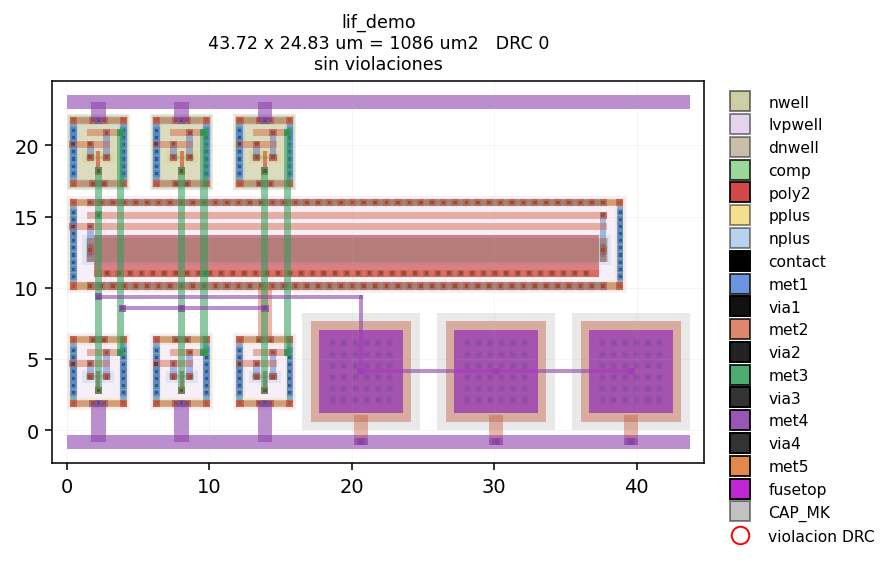

In [9]:
import subprocess
from IPython.display import Image, display

png = '%s/lif_demo.png' % check.SALIDA
lyrdb = '%s/lif_demo.lyrdb' % check.SALIDA
subprocess.run([sys.executable,
                str(raiz / 'designs' / 'scripts' / 'lif_design' / 'preview.py'),
                png, '%s:%s' % (gds, lyrdb)], check=True)
display(Image(filename=png))


## Robustez

Lo anterior es un punto. Lo que importa es que aguante todo el rango que produce la capa
de caracterización, porque esas dimensiones no las elegimos nosotros.

Dos tandas: seis juegos de dimensiones a mano, y cuatro especificaciones recorriendo el
camino completo. Cada caso con DRC (con reglas MIM) y las seis redes.


In [10]:
_ = check.main()


caso         caja um            DRC  topologia
--------------------------------------------------------------------------


base          53.88 x  23.54      0  ok


inv anchos    53.88 x  24.26      0  ok


M5 corto      41.12 x  23.54      0  ok


M5 ancho      53.88 x  25.78      0  ok


...

todo grande   53.88 x  29.50      0  ok

f objetivo   caja um            DRC  topologia
--------------------------------------------------------------------------


200 kHz       53.17 x  29.47      0  ok (3 MIM)


300 kHz       48.70 x  27.40      0  ok (3 MIM)


800 kHz       39.30 x  24.08      0  ok (2 MIM)


2000 kHz      39.30 x  23.01      0  ok (1 MIM)

todos los casos pasan


## Lo que falta

- **Confirmar la receta de MIM con el equipo.** Es una decisión de todo el chip: el PDK
  ofrece 1.0, 1.5 y 2.0 fF/µm² pero un proceso sólo puede usar una, y hace falta una
  máscara extra. Aquí se usa `2f0`, la que menos área pide. `integrator.ipynb` ya usa
  `cap_mim_2f0fF`, pero el comentario de `lif.ipynb` sólo cuadra con `1f0`.
- **Saber cuántos metales tiene el shuttle.** Los rieles van en met4 y met4 ya está
  ocupado dentro de la celda. El DRC no avisa de esto: `metal_level` sólo renombra cuál
  es el metal superior, no comprueba que no haya formas en capas inexistentes.
- Pozo compartido entre los tres pfets, plegado de M5, y soportar `multipliers > 1`, que
  hoy sólo avisa.
